In [16]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---


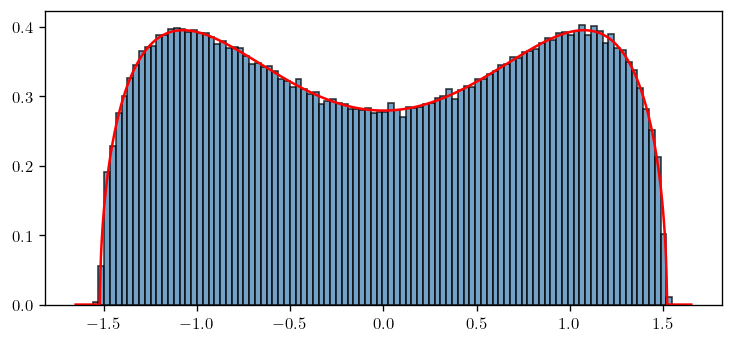

In [19]:
N = 100; beta = 2.0; T = 5.0; M = 250; 
potential_name = "quartic"; num_bins = 100;     
metropolise = False
dt = 0.1

total_steps = int(T/dt); init = random_matrix.init_gue_eigenvalues(M, N)
noise_scale = np.sqrt(2.0*dt/(beta*N))

pipe = simulate.get_pipeline("imla", dt = dt, noise_scale = noise_scale, potential_type = potential_name, beta = beta, metropolise = metropolise)
traj = simulate.simulate_dbm(init, total_steps, pipe)
particles = simulate.collect_snapshots(traj, total_steps)

# Quick plotter.
density_range, limiting_density = densities.get_density(potential_name)

fig, ax = plt.subplots(figsize = (6, 2.75))
ax.hist(particles, bins = num_bins, density = True, color = "steelblue", edgecolor = "black", alpha = 0.75)
ax.plot(density_range, limiting_density, color = "red", lw = 1.5)
ax.grid(False)

plt.show()

In [ ]:
initial_dt = 0.05; M = 50; total_steps = int(10**3); beta = 2;
N_range = [50, 100]
dt_evolution = np.zeros((len(N_range), total_steps + 1))
accept_evolution = np.zeros((len(N_range), total_steps))
dt_evolution[:, 0] = initial_dt
target_prob = 0.25

for j, N in enumerate(N_range):
    x0 = random_matrix.init_gue_eigenvalues(N, M)
    state = np.copy(x0)

    for step_idx in range(total_steps):
        dt = dt_evolution[j, step_idx]
        noise_scale = np.sqrt(2/(beta*N))
        state, acc_rate = integrators.imla_step(state, dt, 
                            potential_int = 2, noise_scale = noise_scale, beta = beta)

        # Update dt.
        new_dt = get_next_step_size(dt, acc_rate, target_prob, step_idx)
        # print(f"Old dt was {dt:.4f}. New {new_dt:.4f} with accept {acc_rate}.")
        # print(f"dt was {dt:.4f} and acc_rate was {acc_rate}. Updated dt to {new_dt:.4f}.")

        dt_evolution[j, step_idx + 1] = new_dt
        accept_evolution[j, step_idx] = acc_rate

# ================================================

final_dts = [dt_evolution[j, -1] for j in range(len(N_range))]

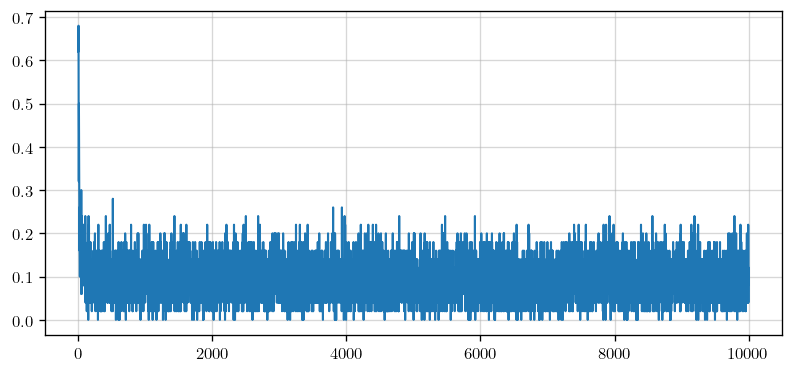

In [58]:
plt.plot(list(range(total_steps)), accept_evolution[0, :])
plt.show()